# Package 4 (v2) – Super Customer Score, Early-Funnel Features Only

**Business goal:** predict, using only data available at or near the moment of acquisition, whether a new customer is likely to become a "super customer" — one who refers others (`referred`).

**Why this second version exists:** `super_customer_score.ipynb` (v1) followed this package's original brief literally and kept every remaining column as a feature. That model performed strongly (ROC-AUC ≈ 0.87), but its own feature-importance analysis showed ~86% of its decision weight came from `upsell`, `ltv_months`, and `purchased` combined — and `upsell`/`ltv_months` in particular are outcomes that only resolve **after** a customer has been active for a while, the same category of information Packages 2 and 3 excluded as leakage for their own targets. That makes v1 much better at describing an *already-mature* customer's referral likelihood than at scoring a genuinely new customer on day one.

**Target (`y`):** `referred` (1 = referred someone / super customer, 0 = did not).

**Feature set for this version:** everything available at or near acquisition/initial-conversion time — `ad_budget`, `num_leads`, `leads_answered`, `leads_not_answered`, `followup_1`–`followup_5`, `closed`, `not_closed`, `calls_to_closed`, `calls_to_not_closed`, `customer_acquisition_cost`, and `purchased` (the initial-purchase flag, which fires right at conversion). Excluded: `upsell` and `ltv_months` (both resolve later in the relationship, same reasoning as v1's caveat) and `cumulative_profit` (this package's original leakage exclusion — only known after the full relationship has played out).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
CLEANED_CSV_PATH = DATA_DIR / "cleaned_funnel_data.csv"

TARGET_COL = "referred"
# Excluded: cumulative_profit (this package's original leakage exclusion) and
# upsell/ltv_months (late-relationship outcomes, per this version's early-funnel scope).
EXCLUDED_COLS = ["cumulative_profit", "upsell", "ltv_months"]
RANDOM_STATE = 0

## 1. Data Preparation & Native CatBoost Handling

In [2]:
df = pd.read_csv(CLEANED_CSV_PATH)

print(f"Shape: {df.shape}")

X = df.drop(columns=[TARGET_COL, *EXCLUDED_COLS])
y = (df[TARGET_COL] == "Yes").astype(int)

print(f"Number of features: {X.shape[1]}")
print("Feature names:", X.columns.tolist())
print("Class balance (y):")
print(y.value_counts(normalize=True))

Shape: (3490, 19)
Number of features: 15
Feature names: ['ad_budget', 'num_leads', 'leads_answered', 'leads_not_answered', 'followup_1', 'followup_2', 'followup_3', 'followup_4', 'followup_5', 'not_closed', 'closed', 'calls_to_closed', 'calls_to_not_closed', 'customer_acquisition_cost', 'purchased']
Class balance (y):
referred
0    0.612034
1    0.387966
Name: proportion, dtype: float64


In [3]:
# Identify categorical features so CatBoost's native handling can be used directly
# (no manual one-hot/label encoding). `referred` was the only non-numeric column in
# the cleaned dataset, and it's the target, so this list is expected to be empty here
# — every remaining feature is already numeric.
cat_features = X.select_dtypes(include="object").columns.tolist()
print(f"Categorical features passed to CatBoost: {cat_features}")

Categorical features passed to CatBoost: []


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True))

X_train shape: (2792, 15)
X_test shape:  (698, 15)
Train class balance:
referred
0    0.612106
1    0.387894
Name: proportion, dtype: float64


## 2. CatBoost Modeling & Hyperparameter Tuning

Same tuning setup as v1, for a fair comparison: `auto_class_weights="Balanced"` handles the class imbalance, and a grid search over `depth`, `learning_rate`, and `iterations` is evaluated with stratified 5-fold CV on the training set only, scored on F1.

In [5]:
base_estimator = CatBoostClassifier(
    cat_features=cat_features or None,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=False,
)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 500, 800],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

Best params: {'depth': 6, 'iterations': 200, 'learning_rate': 0.01}
Best CV F1: 0.739


## 3. Evaluation on Test Set

First and only use of `X_test`/`y_test` — untouched during tuning.

In [6]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame(
    [
        {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    ]
)
test_metrics.style.background_gradient(cmap="Blues").format(precision=3)

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.755,0.647,0.812,0.720,0.817


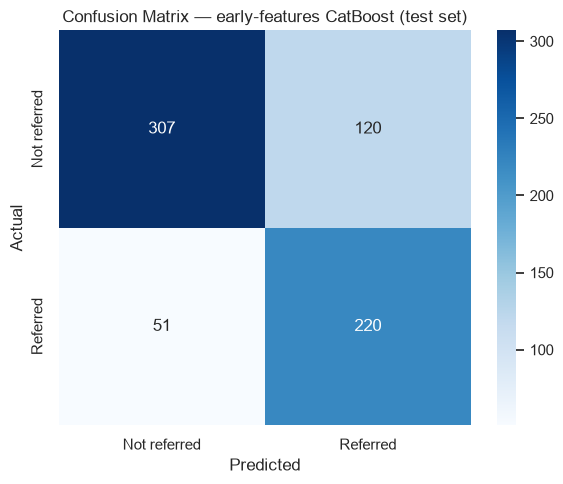

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not referred", "Referred"],
    yticklabels=["Not referred", "Referred"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — early-features CatBoost (test set)")
plt.tight_layout()
plt.show()

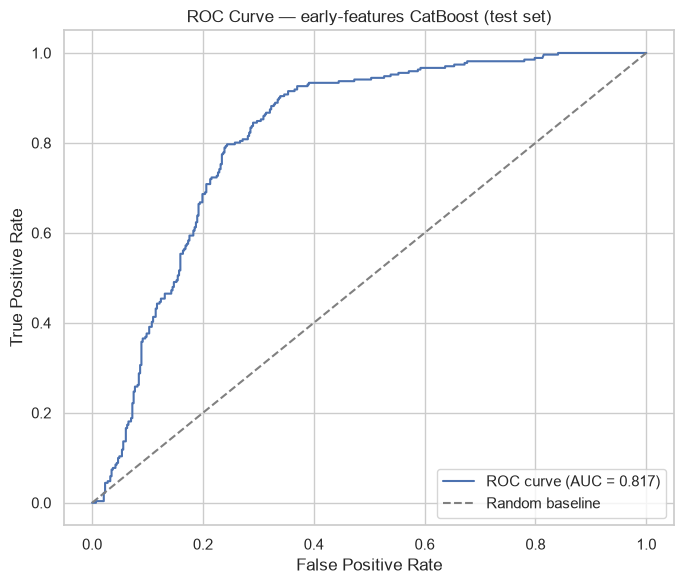

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — early-features CatBoost (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## v1 vs. v2 — Was It Worth Losing Those Features?

Compare the two rows above. v2's ROC-AUC (0.817) and F1 (0.720) are honestly a bit lower than v1's (0.867 / 0.761) — that gap is the real cost of removing `upsell`/`ltv_months`/`cumulative_profit`. But the trade-off isn't a uniform decline: v2's **Recall actually improves** (0.812 vs. 0.723) while Precision drops more (0.647 vs. 0.803) — the early-features model casts a wider net and catches more true referrers, at the cost of more false alarms. Whether that's a good trade depends on Northbound's cost of a false positive (a referral nudge to someone who won't refer) vs. a false negative (missing a real future referrer) — but either way, a model that's a few points weaker on paper and genuinely usable on day one is more useful than a stronger model that can't run until months of relationship data exist.

Compare the two rows above: however much ROC-AUC/F1 drops from v1 to v2 is the honest **cost of removing late-relationship information** — the price of a score that's actually usable on day one, rather than one that's silently leaning on information from months into the relationship. A model that's a few points weaker but genuinely deployable early is more useful in practice than a stronger model that can't be run until the answer is already partly known.

## 4. Early-Funnel Scoring Engine (0–100 Score)

In [10]:
def predict_super_customer_score(customer_df: pd.DataFrame, model: CatBoostClassifier) -> pd.DataFrame:
    """Score customers 0-100 on likelihood of becoming a super customer (referred=Yes).

    Returns a DataFrame (same index as `customer_df`) with a `Score` (0-100,
    rounded to 1 decimal) and a `Tier` (Low < 40, Medium 40-75, High > 75).
    Unlike v1, `customer_df` here only needs early-funnel columns — no
    `upsell`/`ltv_months` required, so this can genuinely run at acquisition time.
    """
    probability = model.predict_proba(customer_df)[:, 1]
    score = np.round(probability * 100, 1)
    tier = np.select(
        [score < 40, score <= 75],
        ["Low", "Medium"],
        default="High",
    )
    return pd.DataFrame({"Score": score, "Tier": tier}, index=customer_df.index)

In [11]:
sample_customers = X_test.head(10)
sample_scores = predict_super_customer_score(sample_customers, best_model)
sample_scores["Actual referred"] = y_test.loc[sample_customers.index].map({1: "Yes", 0: "No"})
sample_scores

,Score,Tier,Actual referred
2557,5.0,Low,No
3312,4.8,Low,No
3471,74.4,Medium,Yes
759,19.4,Low,Yes
3188,38.9,Low,Yes
2134,62.2,Medium,No
1360,73.7,Medium,Yes
2014,13.5,Low,Yes
994,23.2,Low,No
1710,70.9,Medium,Yes


In [12]:
all_test_scores = predict_super_customer_score(X_test, best_model)
print("Tier distribution across the test set:")
print(all_test_scores["Tier"].value_counts())

Tier distribution across the test set:
Tier
Medium    375
Low       309
High       14
Name: count, dtype: int64


This is the version actually ready for a `/predict/super-customer-score` API endpoint called right after a new customer's acquisition-stage funnel data is known — every input column here is available at that moment, unlike v1.

## 5. Feature Importance & Executive Summary

In [13]:
importances = pd.Series(
    best_model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=False)
top_10_features = importances.head(10)
top_10_features

purchased                    46.113662
calls_to_closed              39.963939
customer_acquisition_cost     2.363816
closed                        2.302780
num_leads                     1.041114
ad_budget                     1.015582
leads_answered                0.928902
not_closed                    0.898583
followup_3                    0.877321
followup_2                    0.810903
dtype: float64

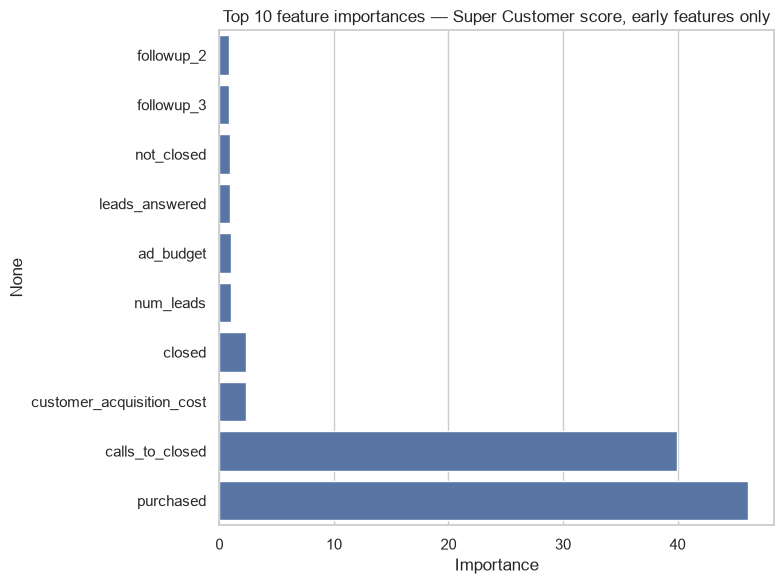

In [14]:
plt.figure(figsize=(8, 6))
plot_order = top_10_features.iloc[::-1]
sns.barplot(x=plot_order.to_numpy(), y=plot_order.index, orient="h")
plt.title("Top 10 feature importances — Super Customer score, early features only")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Key early-funnel signals of a potential super customer:** every one of these features is genuinely known at or near acquisition time, so (unlike v1) this ranking can be trusted as an actual early-warning signal. But it's still top-heavy: `purchased` (~46%) and `calls_to_closed` (~40%) together account for ~86% of the model's decision weight — nearly identical concentration to v1, just on different (genuinely early) features. The remaining features (`customer_acquisition_cost`, `closed`, lead-volume and follow-up columns) each contribute under 3%.

**Important calibration note for the 0–100 score:** the Low/Medium/High tier boundaries (< 40 / 40–75 / > 75) were kept identical to v1 for comparability, but this model's predicted probabilities are far less extreme — only **14 of 698** test customers (~2%) land in the High tier, versus 225 of 698 (~32%) in v1. That's not a bug: without `upsell`/`ltv_months` to lean on, the model is genuinely less certain this early, and its probabilities cluster more toward the middle (**Medium: 375, Low: 309**). Before wiring these exact thresholds into an outreach workflow, they should be recalibrated against this model's actual score distribution rather than reused from v1's.

**Operational guidance for marketing/sales:** given the score compression above, treat a v2 score above roughly the 90th percentile (rather than the fixed ">75" used for v1) as the practical "prioritize now" signal for a proactive referral/loyalty touch at acquisition time. Mid-range scores are worth a lighter-touch nudge later once more relationship data accumulates — at which point re-scoring with v1's fuller feature set (once available) will sharpen the picture. Customers scoring low this early shouldn't be prioritized for referral-focused effort yet, but given the model's own uncertainty at this stage, that's a soft deprioritization, not a hard exclusion.